In [ ]:
# QUESTION 4
import math

def calculate_stirling_factorial(n):
   
    # Formula: ln(n!) ≈ n*ln(n) - n + 0.5*ln(2*pi*n)

    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers.")
    if n == 0:
        return 1.0, 0
    ln_n_factorial = (n * math.log(n)) - n + (0.5 * math.log(2 * math.pi * n))
    log10_val = ln_n_factorial / math.log(10)
    exponent = math.floor(log10_val)
    fractional_part = log10_val - exponent
    mantissa = 10 ** fractional_part

    return mantissa, exponent
n = 62
try:
    m, e = calculate_stirling_factorial(n)
    
    print(f"Stirling's Approximation for {n}!")
    print("-" * 30)
    print(f"Mantissa (M): {m:.5f}")
    print(f"Exponent (E): {e}")
    print("-" * 30)
    print(f"Final Result: {m:.5f} x 10^{e}")

except ValueError as err:
    print(err)


Stirling's Approximation for 62!
------------------------------
Mantissa (M): 3.14277
Exponent (E): 85
------------------------------
Final Result: 3.14277 x 10^85


In [3]:
def ah(n):
    if n==0:
        return 1
    if n==1:
        return 1
    return n*ah(n-1)
print(ah(62))



31469973260387937525653122354950764088012280797258232192163168247821107200000000000000


In [ ]:
print(f"this is the error from this formula {(ah(62)-(m*10**e))*100/(m*10**e)}")
print(m*10**e)

0.13449780399048783
3.142770368908149e+85


In [29]:
import string
help(string)
print(string.ascii_lowercase)
a=[]
for i in string.ascii_lowercase:
    a.append(i)
for i in string.ascii_uppercase:
    a.append(i)
for i in string.digits:
    a.append(i)


print(a)
print(len(a))

Help on module string:

NAME
    string - A collection of string constants.

MODULE REFERENCE
    https://docs.python.org/3.13/library/string.html

    The following documentation is automatically generated from the Python
    source files.  It may be incomplete, incorrect or include features that
    are considered implementation detail and may vary between Python
    implementations.  When in doubt, consult the module reference at the
    location listed above.

DESCRIPTION
    Public module variables:

    whitespace -- a string containing all ASCII whitespace
    ascii_lowercase -- a string containing all ASCII lowercase letters
    ascii_uppercase -- a string containing all ASCII uppercase letters
    ascii_letters -- a string containing all ASCII letters
    digits -- a string containing all ASCII decimal digits
    hexdigits -- a string containing all ASCII hexadecimal digits
    octdigits -- a string containing all ASCII octal digits
    punctuation -- a string containing all A

In [ ]:
# QUESTION 3
from itertools import combinations

class DatabaseOracle:
    def __init__(self):
        self._sets = [
            {1,2,3,4,5}, {4,5,6,7},
            {6,7,8,9}, {1,3,9,10}
        ]
        self.num_sets = len(self._sets)
    
    def get_intersection_size(self, indices):
        if not indices: return 0
        result = self._sets[indices[0]].copy()
        for i in indices[1:]:
            result = result.intersection(self._sets[i])
        return len(result)

def incl(oracle):
    n = oracle.num_sets
    total = 0
    for k in range(1, n+1):
        for combo in combinations(range(n), k):
            size = oracle.get_intersection_size(combo)
            if k % 2 == 1:
                total += size
            else:
                total -= size
    return total

oracle = DatabaseOracle()
print("Unique users across all servers:", incl(oracle))

Unique users across all servers: 10


In [ ]:
class DatabaseOracle:
    def __init__(self):
        self._sets = [
            {1, 2, 3, 4, 5},
            {4, 5, 6, 7},
            {6, 7, 8, 9},
            {1, 3, 9, 10}
        ]
        self.num_sets = len(self._sets)

    def get_intersection_size(self, indices):
        if not indices: return 0
        
        first_idx = indices[0]
        result = self._sets[first_idx].copy()
        
        for i in indices[1:]:
            result = result.intersection(self._sets[i])
            
        return len(result)

def get_union_recursive(oracle, index, current_group):
    if index == oracle.num_sets:
        if len(current_group) == 0:
            return 0
            
        size = oracle.get_intersection_size(current_group)
        
        if len(current_group) % 2 == 1:
            return size
        else:
            return -size

    result_with = get_union_recursive(oracle, index + 1, current_group + [index])
    result_without = get_union_recursive(oracle, index + 1, current_group)
    
    return result_with + result_without

my_oracle = DatabaseOracle()
total_users = get_union_recursive(my_oracle, 0, [])
print(f"Total Unique Users: {total_users}")

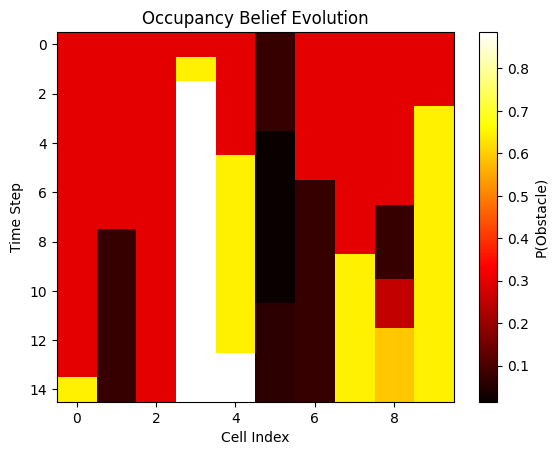

In [ ]:
# QUESTION 1
import numpy as np
import matplotlib.pyplot as plt

n = 10                   
t = 15                   
prior = 0.3               
belief = np.ones(n) * prior
P_z1_O = 0.85   
P_z1_F = 0.20   

history = []

np.random.seed(0)

for t in range(t):
    cell = np.random.randint(0, n) 
    z = np.random.choice([0, 1])    

    P_O = belief[cell]
    P_F = 1 - P_O

    if z == 1:
        num = P_z1_O * P_O
        den = P_z1_O * P_O + P_z1_F * P_F
    else:
        num = (1 - P_z1_O) * P_O
        den = (1 - P_z1_O) * P_O + (1 - P_z1_F) * P_F

    belief[cell] = num / den   
    history.append(belief.copy())

plt.imshow(history, aspect='auto', cmap='hot')
plt.xlabel("Cell Index")
plt.ylabel("Time Step")
plt.colorbar(label="P(Obstacle)")
plt.title("Occupancy Belief Evolution")
plt.show()

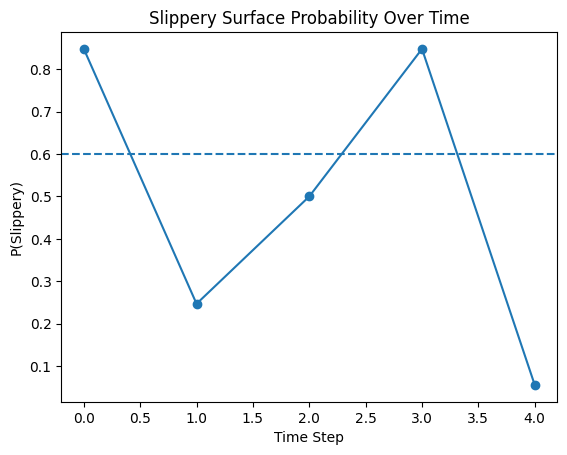

In [ ]:
#QUESION 2
import matplotlib.pyplot as plt
a = 0.30
b = 0.75
c = 0.15
d = 0.65
e = 0.25

def posterior_slippery(W, V):
    if W == 1:
        PW_S, PW_NS = b, c
    else:
        PW_S, PW_NS = 1 - b, 1 - c

    if V == "High":
        PV_S, PV_NS = d,e
    else:
        PV_S, PV_NS = 1 - d, 1 - e

    num = PW_S * PV_S * a
    den = num + PW_NS * PV_NS * (1 - a)
    return num / den

data = [(1,"High"), (0,"High"), (1,"Low"), (1,"High"), (0,"Low")]
probs = [posterior_slippery(W,V) for W,V in data]

plt.plot(probs, marker='o')
plt.axhline(0.6, linestyle='--')
plt.xlabel("Time Step")
plt.ylabel("P(Slippery)")
plt.title("Slippery Surface Probability Over Time")
plt.show()


In [ ]:
class DatabaseOracle:
    def __init__(self):
        self._sets = [
            {1, 2, 3, 4, 5},
            {4, 5, 6, 7},
            {6, 7, 8, 9},
            {1, 3, 9, 10}
        ]
        self.num_sets = len(self._sets)

    def get_intersection_size(self, indices):
        if not indices: return 0
        
        first_idx = indices[0]
        result = self._sets[first_idx].copy()
        
        for i in indices[1:]:
            result = result.intersection(self._sets[i])
            
        return len(result)

def get_union_recursive(oracle, index, current_group):
    if index == oracle.num_sets:
        if len(current_group) == 0:
            return 0
            
        size = oracle.get_intersection_size(current_group)
        
        if len(current_group) % 2 == 1:
            return size
        else:
            return -size

    result_with = get_union_recursive(oracle, index + 1, current_group + [index])
    result_without = get_union_recursive(oracle, index + 1, current_group)
    
    return result_with + result_without

my_oracle = DatabaseOracle()
total_users = get_union_recursive(my_oracle, 0, [])
print(f"Total Unique Users: {total_users}")_
